# 📊 Technical Indicators + Backtesting Engine

## 🔹 Overview
This project provides a **self-contained Python script** that:  
1. Loads **synthetic market data** (guaranteed to run without internet).  
2. Computes multiple **technical indicators** (SMA, EMA, RSI, Bollinger Bands, MACD, OBV, Stochastic, ATR).  
3. Implements **trading strategies** (e.g., SMA crossover, RSI mean-reversion).  
4. Runs a **backtest engine** with equity curves and performance metrics.  

This design allows you to explore and compare trading strategies directly in one cell.

---

## 🔹 Indicators Included
- **SMA (20, 50)** → Simple trend measure.  
- **EMA (21)** → Faster trend measure.  
- **RSI (14)** → Momentum oscillator (30/70 levels).  
- **Bollinger Bands (20, 2σ)** → Volatility bands.  
- **MACD (12, 26, 9)** → Trend + momentum crossover.  
- **OBV** → Volume flow confirmation.  
- **Stochastic (%K, %D)** → Overbought/oversold momentum.  
- **ATR (14)** → Volatility measure for stop-loss sizing.  

---

## 🔹 Strategies Implemented
1. **SMA Crossover (Trend Following)**  
   - Long when SMA20 > SMA50.  
   - Flat when SMA20 < SMA50.  

2. **RSI Contrarian (Mean Reversion)**  
   - Buy when RSI < 30 (oversold).  
   - Exit when RSI > 70 (overbought).  

Both strategies are **long-only** (no short positions).

---

## 🔹 Backtesting Framework
The backtest engine calculates:  
- **Equity curve** (strategy vs buy & hold).  
- **CAGR (Compound Annual Growth Rate)**.  
- **Sharpe Ratio** (risk-adjusted returns).  
- **Max Drawdown (MDD)** (risk measure).  

### Formulas:
- CAGR:  
\[
CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{\tfrac{1}{T_{years}}} - 1
\]

- Sharpe Ratio:  
\[
Sharpe = \frac{E[R - R_f]}{\sigma_R} \times \sqrt{252}
\]

- Max Drawdown:  
\[
MDD = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}
\]

---

## 🔹 Implementation Flow
```python
# 1. Load Data
df = load_synthetic()

# 2. Compute Indicators
df = add_indicators(df)

# 3. Run Strategies
df_sma = sma_crossover(df)
backtest(df_sma, "SMA Crossover")

df_rsi = rsi_strategy(df)
backtest(df_rsi, "RSI Strategy")


In [1]:
print("Hello World!")

Hello World!


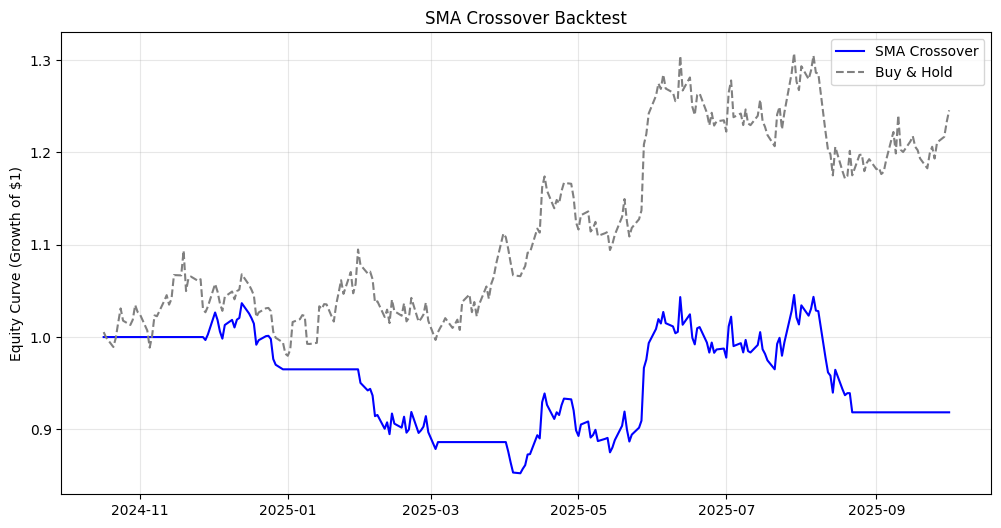

=== SMA Crossover Results ===
CAGR: nan%
Sharpe Ratio: -0.35
Max Drawdown: -17.77%


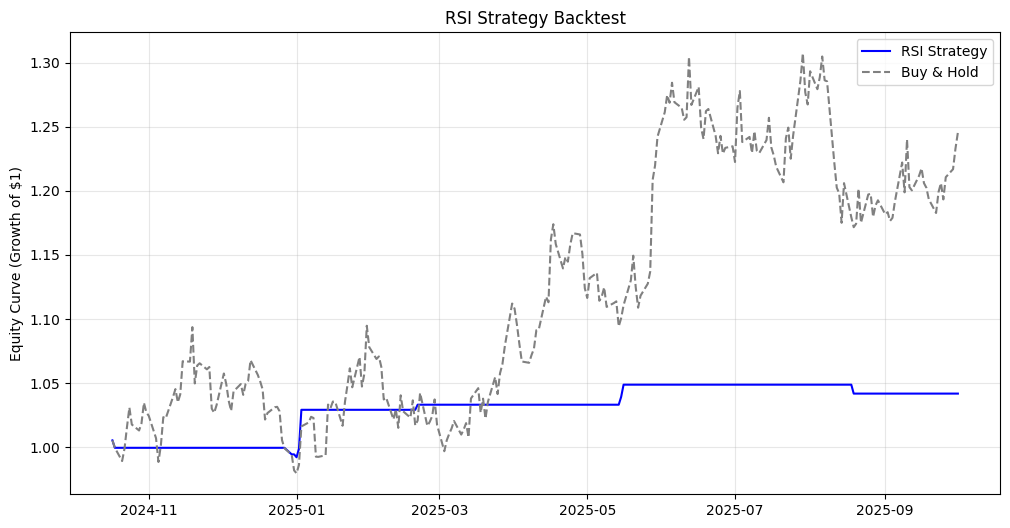

=== RSI Strategy Results ===
CAGR: nan%
Sharpe Ratio: 1.19
Max Drawdown: -1.31%


,High,Low,Close,Volume,SMA20,SMA50,EMA21,RSI14,BB_UP,BB_LOW,...,OBV,%K,%D,ATR14,Signal,Position,Return,Strat_Return,Equity_Strategy,Equity_BuyHold
2024-10-16,86.097805,83.382822,84.882424,2560473,89.487270,95.853128,89.468722,25.990339,95.271672,83.702867,...,-25355151,16.163274,24.193703,2.316752,1,0.0,NaN,NaN,NaN,NaN
2024-10-17,85.543359,84.618362,85.340037,4498472,89.184203,95.543673,89.093387,26.622048,95.167435,83.200971,...,-20856679,25.670840,24.964248,2.217341,1,1.0,0.005391,0.005391,1.005391,1.005391
2024-10-18,86.256970,83.445920,84.847205,4006316,88.719935,95.228197,88.707371,31.377460,94.533847,82.906024,...,-24862995,19.206855,20.346990,2.259749,0,1.0,-0.005775,-0.005775,0.999585,0.999585
2024-10-21,85.181135,83.185817,83.970399,2564718,88.211544,94.873998,88.276737,33.900145,93.815807,82.607281,...,-27427713,10.031388,18.303028,2.240861,0,0.0,-0.010334,-0.000000,0.999585,0.989255
2024-10-22,85.022213,84.114143,84.806328,1945439,87.821441,94.486583,87.961245,36.772435,93.229926,82.412957,...,-25482274,20.719266,16.652503,2.155929,0,0.0,0.009955,0.000000,0.999585,0.999104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-25,101.887424,99.704883,101.289799,4007749,101.779205,103.400695,101.989599,50.377840,104.391966,99.166445,...,43980457,30.535885,40.874741,2.487301,0,0.0,-0.010583,-0.000000,1.041869,1.193295
2025-09-26,103.199474,102.452157,102.763053,4231959,101.855759,103.386881,102.059913,47.276492,104.489535,99.221983,...,48212416,53.659321,43.911985,2.446042,0,0.0,0.014545,0.000000,1.041869,1.210652
2025-09-29,104.705263,103.039009,103.289757,3366610,102.004899,103.404222,102.171717,54.678834,104.608611,99.401187,...,51579026,61.926189,48.707132,2.410054,0,0.0,0.005125,0.000000,1.041869,1.216857
2025-09-30,106.601611,103.096524,104.649054,2068199,102.215118,103.390421,102.396929,47.839134,104.956286,99.473950,...,53647225,73.095393,62.893634,2.488270,0,0.0,0.013160,0.000000,1.041869,1.232871


In [1]:
# ==== Full Technical Indicators + Backtesting ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Data Loader ----------------
def load_synthetic(n=300, seed=42):
    np.random.seed(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    high = close * (1 + np.random.uniform(0.001, 0.02, size=n))
    low  = close * (1 - np.random.uniform(0.001, 0.02, size=n))
    volume = pd.Series(np.random.randint(1e6, 5e6, size=n), index=dates, name="Volume")
    df = pd.DataFrame({"High": high, "Low": low, "Close": close, "Volume": volume})
    return df

# ---------------- Indicators ----------------
def add_indicators(df):
    df = df.copy()

    # SMA / EMA
    df["SMA20"] = df["Close"].rolling(20).mean()
    df["SMA50"] = df["Close"].rolling(50).mean()
    df["EMA21"] = df["Close"].ewm(span=21, adjust=False).mean()

    # RSI
    delta = df["Close"].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    roll_up = pd.Series(gain, index=df.index).rolling(14).mean()
    roll_down = pd.Series(loss, index=df.index).rolling(14).mean()
    RS = roll_up / roll_down.replace(0, np.nan)
    df["RSI14"] = 100 - (100 / (1 + RS))

    # Bollinger Bands
    mid = df["Close"].rolling(20).mean()
    std = df["Close"].rolling(20).std(ddof=0)
    df["BB_UP"], df["BB_LOW"] = mid + 2 * std, mid - 2 * std

    # MACD
    ema_fast = df["Close"].ewm(span=12, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema_fast - ema_slow
    df["MACD_SIG"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_HIST"] = df["MACD"] - df["MACD_SIG"]

    # OBV
    obv = [0]
    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["Close"].iloc[i-1]:
            obv.append(obv[-1] + df["Volume"].iloc[i])
        elif df["Close"].iloc[i] < df["Close"].iloc[i-1]:
            obv.append(obv[-1] - df["Volume"].iloc[i])
        else:
            obv.append(obv[-1])
    df["OBV"] = obv

    # Stochastic Oscillator
    low14 = df["Low"].rolling(14).min()
    high14 = df["High"].rolling(14).max()
    df["%K"] = 100 * (df["Close"] - low14) / (high14 - low14)
    df["%D"] = df["%K"].rolling(3).mean()

    # ATR
    prev_close = df["Close"].shift(1)
    tr1 = df["High"] - df["Low"]
    tr2 = (df["High"] - prev_close).abs()
    tr3 = (df["Low"] - prev_close).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df["ATR14"] = true_range.ewm(alpha=1/14, adjust=False).mean()

    return df

# ---------------- Strategies ----------------
def sma_crossover(df):
    df = df.copy()
    df["Signal"] = 0
    df.loc[df["SMA20"] > df["SMA50"], "Signal"] = 1
    df.loc[df["SMA20"] < df["SMA50"], "Signal"] = 0
    return df

def rsi_strategy(df):
    df = df.copy()
    df["Signal"] = 0
    df.loc[df["RSI14"] < 30, "Signal"] = 1
    df.loc[df["RSI14"] > 70, "Signal"] = 0
    return df

# ---------------- Backtester ----------------
def backtest(df, strat_name="Strategy"):
    df = df.copy().dropna()
    df["Position"] = df["Signal"].shift(1).fillna(0)
    df["Return"] = df["Close"].pct_change()
    df["Strat_Return"] = df["Position"] * df["Return"]

    df["Equity_Strategy"] = (1 + df["Strat_Return"]).cumprod()
    df["Equity_BuyHold"] = (1 + df["Return"]).cumprod()

    def CAGR(series):
        years = (series.index[-1] - series.index[0]).days / 365
        return (series.iloc[-1]/series.iloc[0])**(1/years) - 1 if years>0 else np.nan

    def sharpe(returns, rf=0.0):
        return (returns.mean() - rf) / returns.std() * np.sqrt(252)

    def max_drawdown(series):
        roll_max = series.cummax()
        dd = (series - roll_max) / roll_max
        return dd.min()

    cagr_strat = CAGR(df["Equity_Strategy"])
    sharpe_strat = sharpe(df["Strat_Return"].dropna())
    mdd_strat = max_drawdown(df["Equity_Strategy"])

    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(df.index, df["Equity_Strategy"], label=strat_name, color="blue")
    ax.plot(df.index, df["Equity_BuyHold"], label="Buy & Hold", color="gray", linestyle="--")
    ax.set_title(f"{strat_name} Backtest")
    ax.set_ylabel("Equity Curve (Growth of $1)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    print(f"=== {strat_name} Results ===")
    print(f"CAGR: {cagr_strat:.2%}")
    print(f"Sharpe Ratio: {sharpe_strat:.2f}")
    print(f"Max Drawdown: {mdd_strat:.2%}")

    return df

# ---------------- Main Run ----------------
df = load_synthetic()
df = add_indicators(df)

# Run SMA crossover strategy
df_sma = sma_crossover(df)
backtest(df_sma, "SMA Crossover")

# Run RSI strategy
df_rsi = rsi_strategy(df)
backtest(df_rsi, "RSI Strategy")
